In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"..\Datasets\maintenance_data.csv")
df

,lifetime,broken,pressureInd,moistureInd,temperatureInd,team,provider
0,56,0,92.178854,104.230204,96.517159,TeamA,Provider4
1,81,1,72.075938,103.065701,87.271062,TeamC,Provider4
2,60,0,96.272254,77.801376,112.196170,TeamA,Provider1
3,86,1,94.406461,108.493608,72.025374,TeamC,Provider2
4,34,0,97.752899,99.413492,103.756271,TeamB,Provider1
...,...,...,...,...,...,...,...
995,88,1,88.589759,112.167556,99.861456,TeamB,Provider4
996,88,1,116.727075,110.871332,95.075631,TeamA,Provider4
997,22,0,104.026778,88.212873,83.221220,TeamB,Provider1
998,78,0,104.911649,104.257296,83.421491,TeamA,Provider4


In [3]:
df.columns

Index(['lifetime', 'broken', 'pressureInd', 'moistureInd', 'temperatureInd',
       'team', 'provider'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   lifetime        1000 non-null   int64  
 1   broken          1000 non-null   int64  
 2   pressureInd     1000 non-null   float64
 3   moistureInd     1000 non-null   float64
 4   temperatureInd  1000 non-null   float64
 5   team            1000 non-null   object 
 6   provider        1000 non-null   object 
dtypes: float64(3), int64(2), object(2)
memory usage: 54.8+ KB


In [5]:
df.dtypes

lifetime            int64
broken              int64
pressureInd       float64
moistureInd       float64
temperatureInd    float64
team               object
provider           object
dtype: object

In [6]:
df.isnull().sum()

lifetime          0
broken            0
pressureInd       0
moistureInd       0
temperatureInd    0
team              0
provider          0
dtype: int64

In [7]:
for i in ['team', 'provider']: print(i,':\n',df[i].unique())

team :
 ['TeamA' 'TeamC' 'TeamB']
provider :
 ['Provider4' 'Provider1' 'Provider2' 'Provider3']


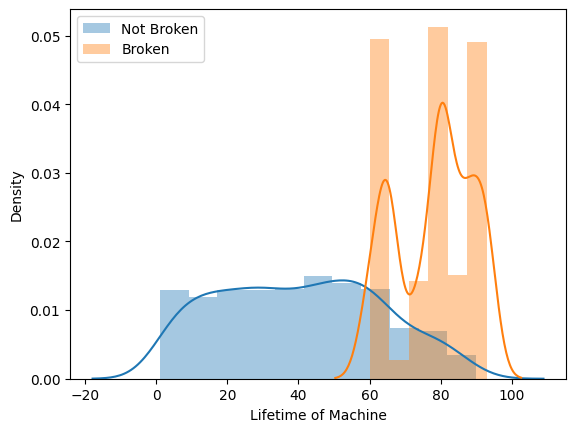

In [8]:
sns.distplot(df.lifetime[df.broken == 0], label = 'Not Broken')
sns.distplot(df.lifetime[df.broken == 1], label = 'Broken')
plt.xlabel('Lifetime of Machine')
plt.legend()
plt.show()

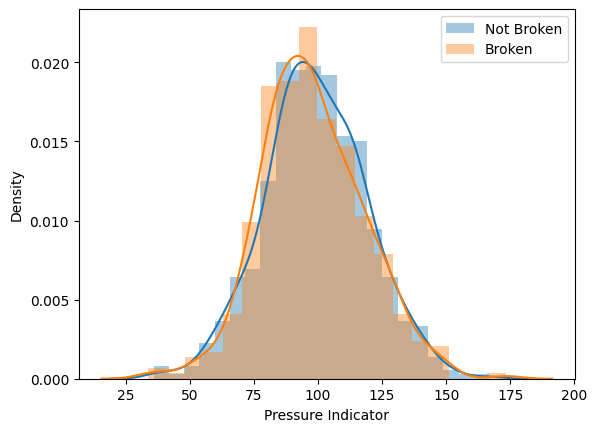

In [9]:
sns.distplot(df.pressureInd[df.broken == 0], label = 'Not Broken')
sns.distplot(df.pressureInd[df.broken == 1], label = 'Broken')
plt.xlabel('Pressure Indicator')
plt.legend()
plt.show()

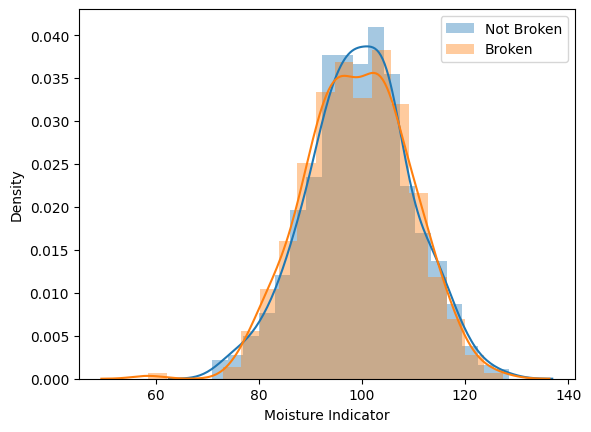

In [10]:
sns.distplot(df.moistureInd[df.broken == 0], label = 'Not Broken')
sns.distplot(df.moistureInd[df.broken == 1], label = 'Broken')
plt.xlabel('Moisture Indicator')
plt.legend()
plt.show()

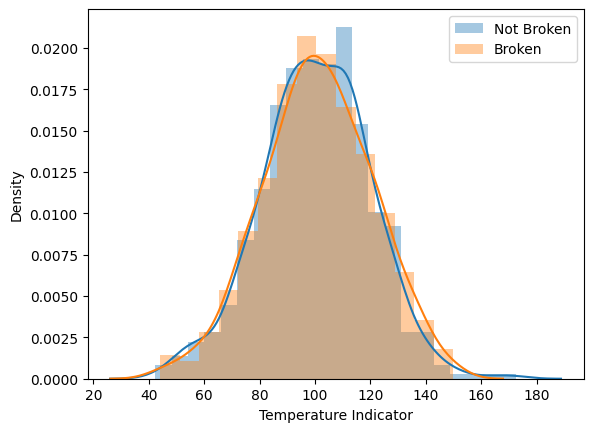

In [11]:
sns.distplot(df.temperatureInd[df.broken == 0], label = 'Not Broken')
sns.distplot(df.temperatureInd[df.broken == 1], label = 'Broken')
plt.xlabel('Temperature Indicator')
plt.legend()
plt.show()

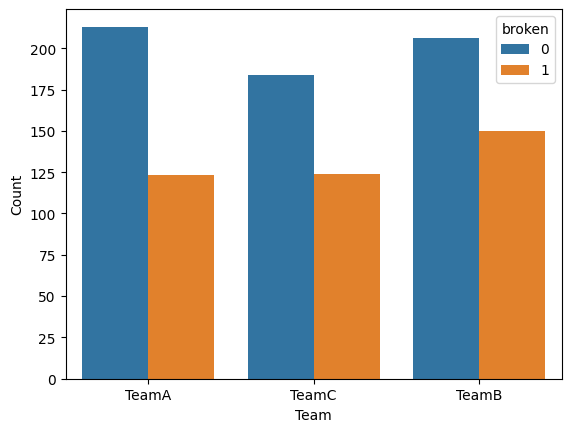

In [12]:
sns.countplot(x = df.team, hue = df.broken)
plt.xlabel('Team')
plt.ylabel('Count')
plt.show()

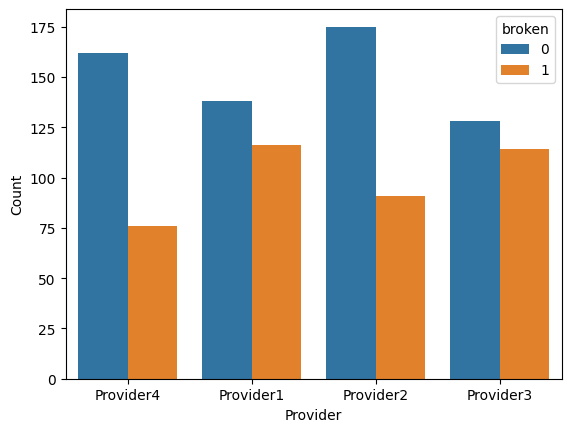

In [13]:
sns.countplot(x = df.provider, hue = df.broken)
plt.xlabel('Provider')
plt.ylabel('Count')
plt.show()

In [14]:
df1 = df
df1

,lifetime,broken,pressureInd,moistureInd,temperatureInd,team,provider
0,56,0,92.178854,104.230204,96.517159,TeamA,Provider4
1,81,1,72.075938,103.065701,87.271062,TeamC,Provider4
2,60,0,96.272254,77.801376,112.196170,TeamA,Provider1
3,86,1,94.406461,108.493608,72.025374,TeamC,Provider2
4,34,0,97.752899,99.413492,103.756271,TeamB,Provider1
...,...,...,...,...,...,...,...
995,88,1,88.589759,112.167556,99.861456,TeamB,Provider4
996,88,1,116.727075,110.871332,95.075631,TeamA,Provider4
997,22,0,104.026778,88.212873,83.221220,TeamB,Provider1
998,78,0,104.911649,104.257296,83.421491,TeamA,Provider4


In [15]:
le1 = LabelEncoder()
le1

LabelEncoder()

In [16]:
df1.team = le1.fit_transform(df1.team)

In [17]:
le1.inverse_transform([2, 1, 0])

array(['TeamC', 'TeamB', 'TeamA'], dtype=object)

In [18]:
le2 = LabelEncoder()
le2

LabelEncoder()

In [19]:
df1.provider = le2.fit_transform(df1.provider)

In [20]:
le2.inverse_transform([3, 2, 1, 0])

array(['Provider4', 'Provider3', 'Provider2', 'Provider1'], dtype=object)

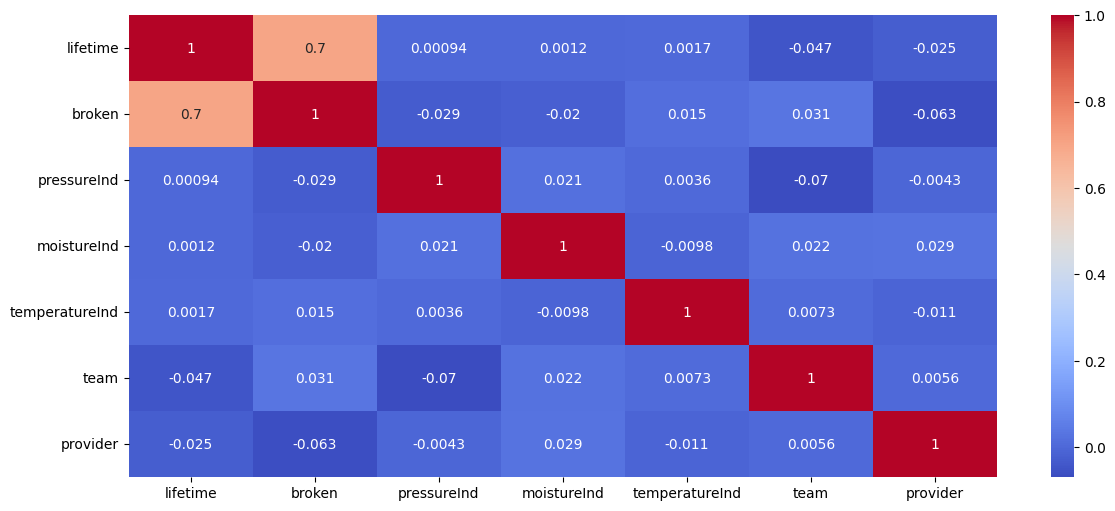

In [21]:
plt.figure(figsize = (14,6))
sns.heatmap(df1.corr(), annot = True, cmap = 'coolwarm')
plt.yticks(rotation = 0)
plt.show()

In [22]:
ip = df1.drop(['broken'], axis = 1)
ip

,lifetime,pressureInd,moistureInd,temperatureInd,team,provider
0,56,92.178854,104.230204,96.517159,0,3
1,81,72.075938,103.065701,87.271062,2,3
2,60,96.272254,77.801376,112.196170,0,0
3,86,94.406461,108.493608,72.025374,2,1
4,34,97.752899,99.413492,103.756271,1,0
...,...,...,...,...,...,...
995,88,88.589759,112.167556,99.861456,1,3
996,88,116.727075,110.871332,95.075631,0,3
997,22,104.026778,88.212873,83.221220,1,0
998,78,104.911649,104.257296,83.421491,0,3


In [23]:
op = df1['broken']
op

0      0
1      1
2      0
3      1
4      0
      ..
995    1
996    1
997    0
998    0
999    0
Name: broken, Length: 1000, dtype: int64

In [24]:
ct = ColumnTransformer([('team', OneHotEncoder(), [4]),
                        ('provider', OneHotEncoder(), [5])], remainder = 'passthrough')
ct

ColumnTransformer(remainder='passthrough',
                  transformers=[('team', OneHotEncoder(), [4]),
                                ('provider', OneHotEncoder(), [5])])

In [25]:
ip = np.array(ct.fit_transform(ip), dtype = str)
ip

array([['1.0', '0.0', '0.0', ..., '92.17885406', '104.2302045',
        '96.51715873'],
       ['0.0', '0.0', '1.0', ..., '72.07593772', '103.0657014',
        '87.27106218'],
       ['1.0', '0.0', '0.0', ..., '96.27225443', '77.80137602',
        '112.1961703'],
       ...,
       ['0.0', '1.0', '0.0', ..., '104.0267784', '88.21287267',
        '83.22122036'],
       ['1.0', '0.0', '0.0', ..., '104.9116487', '104.2572957',
        '83.42149109'],
       ['0.0', '1.0', '0.0', ..., '116.9013541', '99.99869359',
        '47.64149344']], dtype='<U32')

In [26]:
x_train, x_test, y_train, y_test = train_test_split(ip, op, train_size = 0.7)
df.shape, x_train.shape, x_test.shape

((1000, 7), (700, 11), (300, 11))

In [27]:
sc = StandardScaler()
sc

StandardScaler()

In [28]:
x_train = sc.fit_transform(x_train)
x_test = sc.fit_transform(x_test)

In [29]:
log = LogisticRegression()
log.fit(x_train, y_train)

LogisticRegression()

In [30]:
ycap = log.predict(x_test)
ycap

array([0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0], d

In [31]:
pdf = pd.DataFrame({'y':list(y_test),
                    'Prediction':ycap})
pdf

,y,Prediction
0,0,0
1,1,1
2,0,0
3,1,1
4,1,1
...,...,...
295,1,1
296,0,0
297,1,1
298,0,0


In [32]:
cm = confusion_matrix(y_test, ycap)
pd.DataFrame(cm)

,0,1
0,163,8
1,0,129


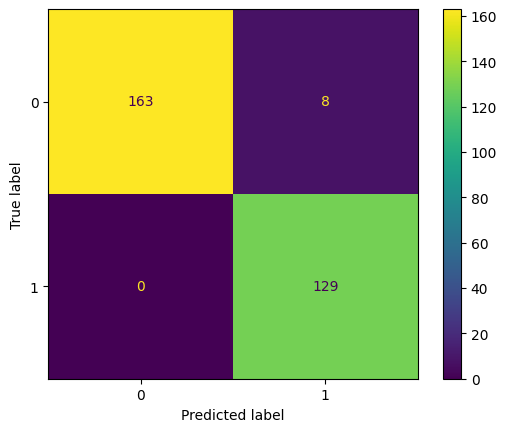

In [33]:
cmd = ConfusionMatrixDisplay(cm)
cmd.plot()
plt.show()

In [34]:
acs = accuracy_score(y_test, ycap)
rcs = recall_score(y_test, ycap)
prs = precision_score(y_test, ycap)
f1s = f1_score(y_test, ycap)
print("Accuracy Score:", acs)
print("Recall Score:", rcs)
print("Precision Score:", prs)
print("F1 Score:", f1s)

Accuracy Score: 0.9733333333333334
Recall Score: 1.0
Precision Score: 0.9416058394160584
F1 Score: 0.9699248120300751
